In [ ]:
import os
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Define and create the state folder
DRIVE_PATH = '/content/drive/MyDrive/advance_ml_project'
REGULARIZED_MODEL = DRIVE_PATH + '/tuned_with_regularization'
NON_REGULARIZED_MODEL = DRIVE_PATH + '/tuned_without_regularization'

assert(os.path.exists(DRIVE_PATH))
assert(os.path.exists(REGULARIZED_MODEL))
assert(os.path.exists(NON_REGULARIZED_MODEL))

BASE_MODEL = 'TechWolf/JobBERT-v2'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Model: /content/drive/MyDrive/advance_ml_project/tuned_with_regularization
t1=0.800, t2=0.862, val_f1=0.4458
               precision    recall  f1-score   support

     Good Fit       0.40      0.32      0.35       257
       No Fit       0.67      0.68      0.67       502
Potential Fit       0.31      0.37      0.34       241

     accuracy                           0.51      1000
    macro avg       0.46      0.45      0.45      1000
 weighted avg       0.51      0.51      0.51      1000



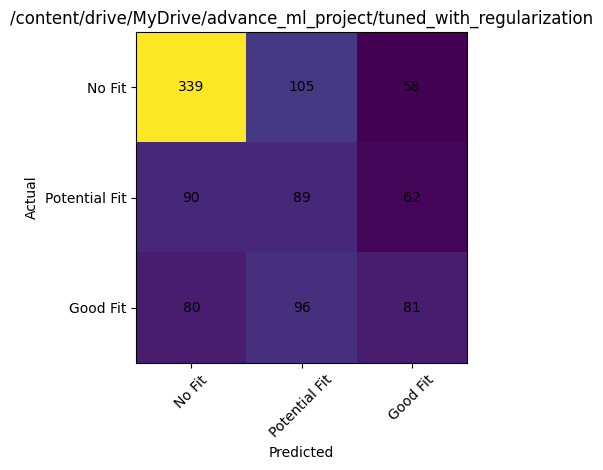

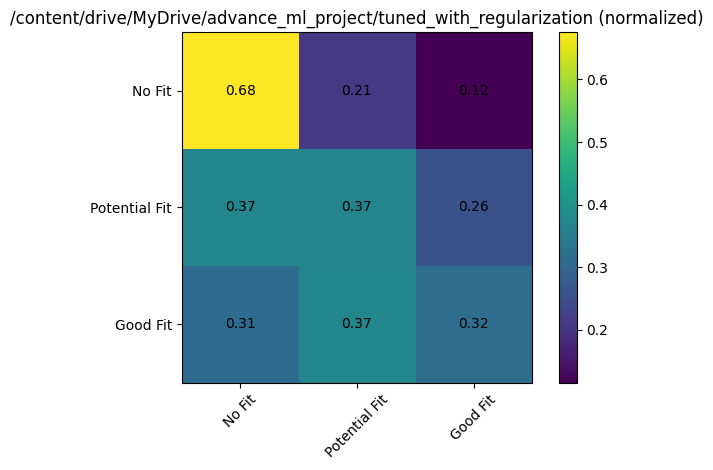

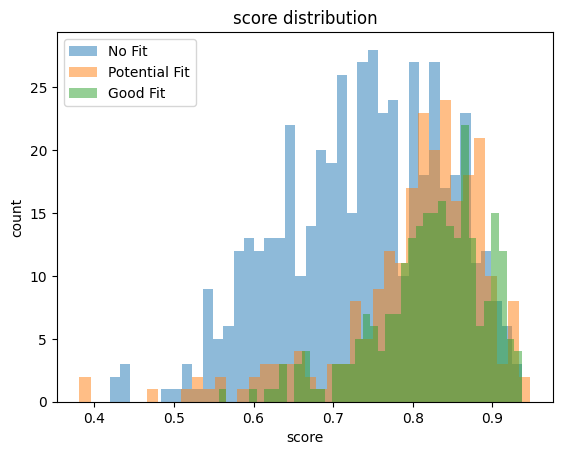

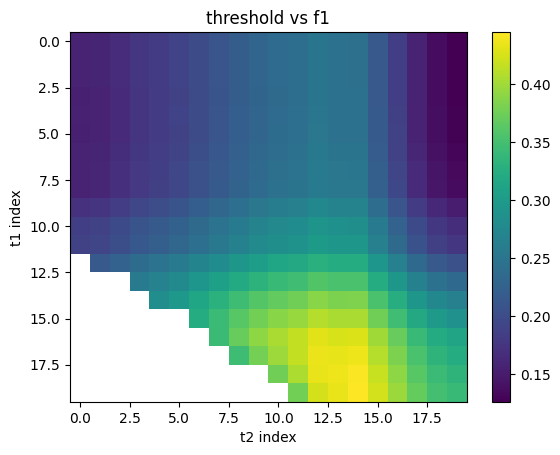

errors:
              label           pred     score
3989  Potential Fit         No Fit  0.381448
3899  Potential Fit         No Fit  0.733981
813          No Fit  Potential Fit  0.846499
4548  Potential Fit         No Fit  0.726437
1822         No Fit  Potential Fit  0.846181


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Model: /content/drive/MyDrive/advance_ml_project/tuned_without_regularization
t1=0.800, t2=0.862, val_f1=0.4472
               precision    recall  f1-score   support

     Good Fit       0.39      0.37      0.38       257
       No Fit       0.71      0.65      0.68       502
Potential Fit       0.31      0.38      0.34       241

     accuracy                           0.51      1000
    macro avg       0.47      0.47      0.47      1000
 weighted avg       0.53      0.51      0.52      1000



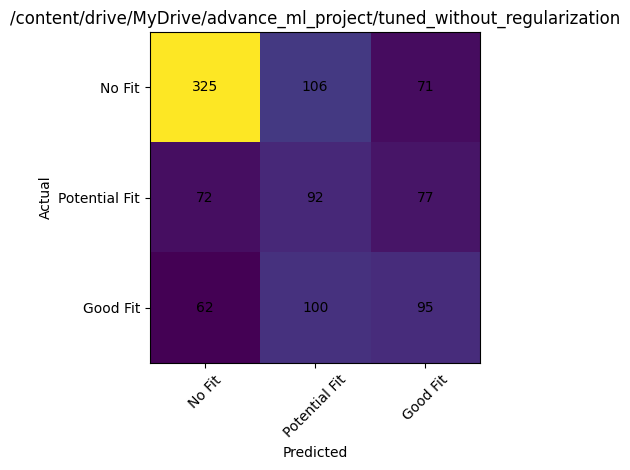

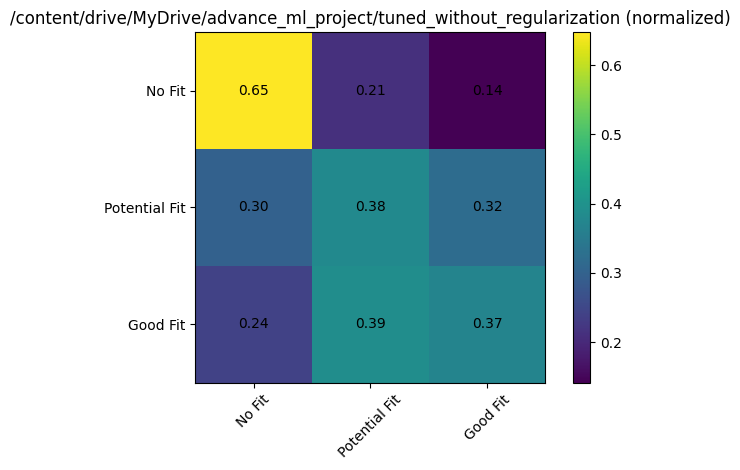

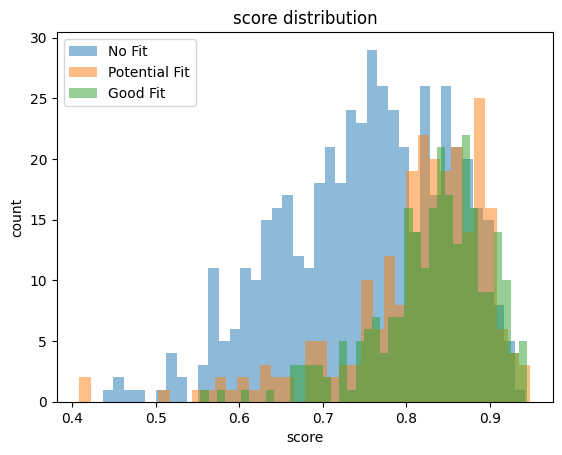

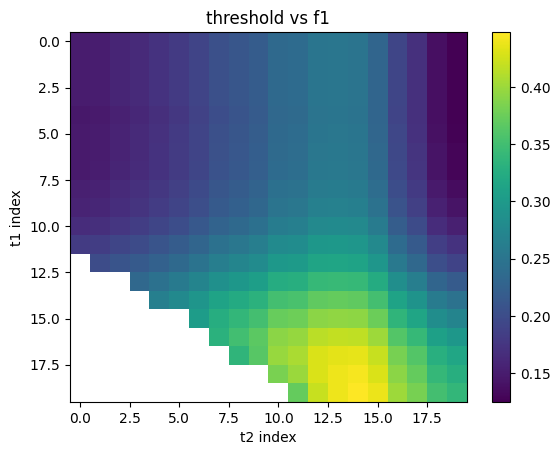

errors:
              label           pred     score
3989  Potential Fit         No Fit  0.408523
3899  Potential Fit         No Fit  0.746657
813          No Fit  Potential Fit  0.850612
4548  Potential Fit         No Fit  0.762737
1822         No Fit  Potential Fit  0.858140

final summary:
                                               model  accuracy  \
0  /content/drive/MyDrive/advance_ml_project/tune...     0.509   
1  /content/drive/MyDrive/advance_ml_project/tune...     0.512   

   precision_macro  recall_macro  f1_macro  f1_weighted   t1      t2  
0         0.458631      0.453256  0.453184     0.508344  0.8  0.8625  
1         0.469244      0.466268  0.465917     0.519473  0.8  0.8625  


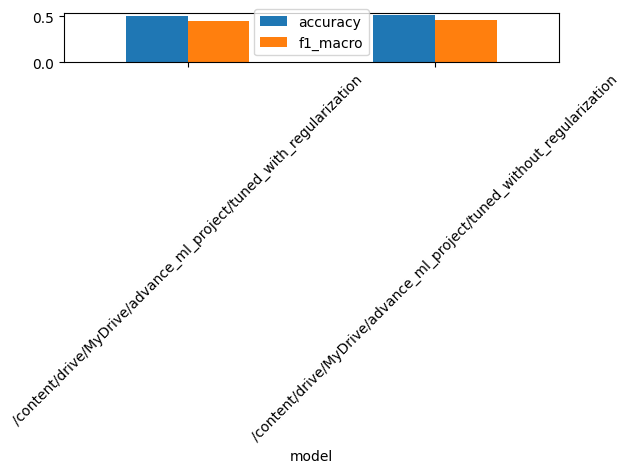

In [ ]:
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, f1_score, accuracy_score,
    precision_score, recall_score, classification_report
)
from sentence_transformers import SentenceTransformer, util

LABELS = ["No Fit", "Potential Fit", "Good Fit"]

def clean_text(x):
    if pd.isna(x):
        return x
    x = str(x)
    x = re.sub(r'[\r\n]+', ' ', x)
    x = re.sub(r'\s+', ' ', x)
    return x.strip()

def load_df_from_csv(f):
    return pd.read_csv(f).map(clean_text).reset_index(drop=True)

df = load_df_from_csv(DRIVE_PATH + "/dataset_1/jd_fit_train.csv")

# split
df_val = df.sample(frac=0.2, random_state=42)
df_test = df.drop(df_val.index).sample(1000, random_state=42)

def compute_scores(df, model):
    emb1 = model.encode(df["resume_text"].tolist(), convert_to_tensor=True)
    emb2 = model.encode(df["job_description_text"].tolist(), convert_to_tensor=True)
    return util.cos_sim(emb1, emb2).diagonal().cpu().numpy()

def predict(scores, t1, t2):
    preds = []
    for s in scores:
        if s < t1:
            preds.append("No Fit")
        elif s < t2:
            preds.append("Potential Fit")
        else:
            preds.append("Good Fit")
    return np.array(preds)

def find_best_thresholds(scores, y_true):
    t1_range = np.linspace(0.3, 0.8, 25)
    t2_range = np.linspace(0.6, 0.95, 25)

    best_f1 = -1
    best_t1, best_t2 = 0.707, 0.856

    for t1 in t1_range:
        for t2 in t2_range:
            if t2 <= t1:
                continue

            preds = [
                "No Fit" if s < t1 else
                "Potential Fit" if s < t2 else
                "Good Fit"
                for s in scores
            ]

            f1 = f1_score(y_true, preds, average="macro")

            if f1 > best_f1:
                best_f1 = f1
                best_t1, best_t2 = t1, t2

    return best_t1, best_t2, best_f1

def plot_confusion_matrix(cm, title):
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xticks(range(len(LABELS)), LABELS, rotation=45)
    plt.yticks(range(len(LABELS)), LABELS)

    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

def plot_normalized_cm(cm, title):
    cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    plt.figure()
    plt.imshow(cm)
    plt.title(title + " (normalized)")
    plt.colorbar()

    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            plt.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center")

    plt.xticks(range(len(LABELS)), LABELS, rotation=45)
    plt.yticks(range(len(LABELS)), LABELS)
    plt.tight_layout()
    plt.show()

def plot_model_comparison(df):
    df.set_index("model")[["accuracy", "f1_macro"]].plot(kind="bar")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_score_distribution(df, scores):
    plt.figure()
    for label in LABELS:
        mask = df["label"] == label
        plt.hist(scores[mask], bins=40, alpha=0.5, label=label)
    plt.legend()
    plt.title("score distribution")
    plt.xlabel("score")
    plt.ylabel("count")
    plt.show()

def plot_threshold_heatmap(scores, y_true):
    t1_range = np.linspace(0.3, 0.8, 20)
    t2_range = np.linspace(0.6, 0.95, 20)

    grid = np.zeros((len(t1_range), len(t2_range)))

    for i, t1 in enumerate(t1_range):
        for j, t2 in enumerate(t2_range):
            if t2 <= t1:
                grid[i, j] = np.nan
                continue

            preds = [
                "No Fit" if s < t1 else
                "Potential Fit" if s < t2 else
                "Good Fit"
                for s in scores
            ]

            grid[i, j] = f1_score(y_true, preds, average="macro")

    plt.figure()
    plt.imshow(grid, aspect='auto')
    plt.colorbar()
    plt.title("threshold vs f1")
    plt.xlabel("t2 index")
    plt.ylabel("t1 index")
    plt.show()

def evaluate_models(models, df_val, df_test):
    summary = []

    for m in models:
        model = SentenceTransformer(m)

        val_scores = compute_scores(df_val, model)
        val_mask = df_val["label"].isin(LABELS)
        y_val = df_val.loc[val_mask, "label"].values
        val_scores = val_scores[val_mask]

        t1, t2, best_f1 = find_best_thresholds(val_scores, y_val)

        test_scores = compute_scores(df_test, model)
        test_mask = df_test["label"].isin(LABELS)
        y_test = df_test.loc[test_mask, "label"].values
        test_scores = test_scores[test_mask]

        preds = predict(test_scores, t1, t2)

        cm = confusion_matrix(y_test, preds, labels=LABELS)

        acc = accuracy_score(y_test, preds)
        precision = precision_score(y_test, preds, average="macro")
        recall = recall_score(y_test, preds, average="macro")
        f1 = f1_score(y_test, preds, average="macro")
        f1_weighted = f1_score(y_test, preds, average="weighted")

        summary.append({
            "model": m,
            "accuracy": acc,
            "precision_macro": precision,
            "recall_macro": recall,
            "f1_macro": f1,
            "f1_weighted": f1_weighted,
            "t1": t1,
            "t2": t2
        })

        print(f"\nModel: {m}")
        print(f"t1={t1:.3f}, t2={t2:.3f}, val_f1={best_f1:.4f}")
        print(classification_report(y_test, preds))

        plot_confusion_matrix(cm, m)
        plot_normalized_cm(cm, m)
        plot_score_distribution(df_test.loc[test_mask], test_scores)
        plot_threshold_heatmap(val_scores, y_val)

        errors = df_test.loc[test_mask].copy()
        errors["pred"] = preds
        errors["score"] = test_scores

        wrong = errors[errors["label"] != errors["pred"]]
        print("errors:")
        print(wrong[["label", "pred", "score"]].head())

    return pd.DataFrame(summary)


models = [REGULARIZED_MODEL, NON_REGULARIZED_MODEL]

results_df = evaluate_models(models, df_val, df_test)

print("\nfinal summary:")
print(results_df)

plot_model_comparison(results_df)

Model is trained on 9k rows by splitting into training, validation and testing set with single epoch (due to time and resource constraint) with batch size of 16. Two kinds of trained model is obtained: regularized and non-regularized.

New set of data is used for testing which has classed such as No Fit, Potential Fit and Good Fit label on it. However, model is designed and trained to obtain similarity score. Score limit is used to classify into one of the mentioned label.
For the above experiment the obtained result was presented in adjacency matrix. The trained models exhibitted lower macro F1-score compared to base model. This is due to increased False Positive results. However, by setting higher threshold for each label, trained model performs better than the base model.